---
title: From Tidy to Wide Without Aggregating
subtitle: DS 2023 | Communicating with Data
---

## Overview

The previous notebook, **Two Ways from Tidy to Wide**, assumed the following:

- You have a tidy DataFrame $D$ with two grouping variables $g_1$ and $g_2$ and one measurement variable $m$.

- You want a wide table $W$ with $g_1$ on axis 0, $g_2$ on axis 1, and $m$ in the cells.

It then split on a single condition: do $g_1$ and $g_2$ combine to produce a unique set over the observations? If yes, reshape. If no, aggregate and reshape.

This notebook takes up the case where **aggregating is not acceptable**.

That case arises constantly once we start plotting distributions. A histogram, a density plot, and a box plot each require every observation. Replacing a group with its mean destroys the very thing we are trying to draw.

It also has a different shape from the outset:

- You have a tidy DataFrame $D$ with **one** grouping variable $g$ and one measurement variable $m$.

- You want a wide table $W$ with $g$ on axis 1 and every value of $m$ running down the columns.

- Reshaping needs two grouping variables, and you have one.

The solution is to manufacture the one you are missing. We will call it $w$, a **within-group ID**.

This will the ID of the observation that will be unique within each group.

When we reshape, $w$ plays the role of $g_1$ and lands on axis 0, and $g$ plays the role of $g_2$ and lands on axis 1.

## Flowchart

This flowchart extends the one from the previous notebook. The first decision is the same. The second is new.

```mermaid
flowchart TD

    C["Check if g1 x g2 combinations are unique over D by using D.value_counts(['g1','g2'])"]

    C --> D{"Does every count == 1?"}

    D -->|"Yes: each pair occurs<br>at most once"| E["Pure reshape<br>(see Two Ways from Tidy to Wide)"]

    D -->|"No: some pairs repeat"| F{"Is one summary value<br>per cell acceptable?"}

    F -->|"Yes: collapse the group"| G["Aggregate and reshape<br>(see Two Ways from Tidy to Wide)"]

    F -->|"No: every observation<br>must be kept"| H["Manufacture w, a within-group ID<br>D['w'] = D.groupby('g').cumcount()"]

    H --> H1["D.pivot(index='w',<br>columns='g',<br>values='m')"]

    H --> H2["D.set_index(['w','g'])['m']<br>.unstack('g')"]

    H1 --> Z["W: rows = position within group, cols = G levels, cells = M"]

    H2 --> Z

    classDef unique fill:#d8f0d8,stroke:#4a8a4a,color:#1c3a1c
    classDef dup fill:#fde4d4,stroke:#c07a45,color:#4a2a12
    classDef new fill:#d9e6f7,stroke:#41689e,color:#16283f
    class E unique
    class G dup
    class H,H1,H2 new
```

## Example 1

We use `iris`, which records four measurements for $150$ flowers of three species.

### Get the data

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Choose the variables

Note that we have only one grouping variable. We assign $g$ and $m$.

In [28]:
a_g = 'species'
a_m = 'petal_length'

### Check for uniqueness

With only one grouping variable, the question is whether $g$ alone identifies a row.

Value counts returns results in descending order, so any values greater than 1 would appear first.

In [29]:
iris.value_counts([a_g]).head(1)

species
setosa     50
Name: count, dtype: int64

We see that `species` is not unique. 

There are $50$ flowers of each species.

By the previous notebook we would now aggregate. 

But we want a box plot, so we need all $150$ measurements. We continue down the new branch.

### See what goes wrong without an index

It is worth seeing what Pandas does if we ask for the reshape and give it no index.

In [32]:
staircase = iris.pivot(columns=a_g, values=a_m)

print('shape:      ', staircase.shape)
print('total cells:', staircase.size)
print('cells filled:', staircase.notna().sum().sum())

staircase.iloc[48:53]

shape:       (150, 3)
total cells: 450
cells filled: 150


species,setosa,versicolor,virginica
48,1.5,NaN,NaN
49,1.4,NaN,NaN
50,NaN,4.7,NaN
51,NaN,4.5,NaN
52,NaN,4.9,NaN


So, no error was raised &mdash; but the table is useless.

Lacking an index, Pandas used the dataframe's original row numbers. Every original row number belongs to exactly one species, so each row holds one value and two blanks. The result is $150$ values scattered across $450$ cells in a staircase.

What we need is a row label meaning **the nth flower of its species**, so that the first setosa, the first versicolor, and the first virginica all land on row $0$.

### Manufacture $w$

The method is `.cumcount()`. Applied to a `groupby` object, it numbers the rows within each group, starting at $0$ and starting over at each new group.

In [5]:
a_w = 'within'

iris[a_w] = iris.groupby(a_g).cumcount()

The behavior to notice is what happens at a group boundary. `iris` is ordered by species, so the change occurs at row $50$.

In [6]:
iris.loc[48:52, [a_g, a_m, a_w]]

,species,petal_length,within
48,setosa,1.5,48
49,setosa,1.4,49
50,versicolor,4.7,0
51,versicolor,4.5,1
52,versicolor,4.9,2


The counter reaches $49$ at the last setosa and resets to $0$ at the first versicolor.

Each species is therefore numbered $0$ through $49$, and $w \times g$ is now unique. We can verify this with the same check we used above.

In [7]:
iris.value_counts([a_w, a_g]).head(1)

within  species
0       setosa     1
Name: count, dtype: int64

### Reshape

Having manufactured $w$, both methods from the previous notebook apply unchanged, with $w$ in the $g_1$ position and $g$ in the $g_2$ position.

#### Method 1: Pivoting

In [8]:
iris.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


#### Method 2: Unstacking

In [9]:
iris.set_index([a_w, a_g])[a_m].unstack().head()

species,setosa,versicolor,virginica
within,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


The staircase has collapsed from $150$ rows into $50$, with every cell filled.

$W$ is now in the shape our plotting functions expect.

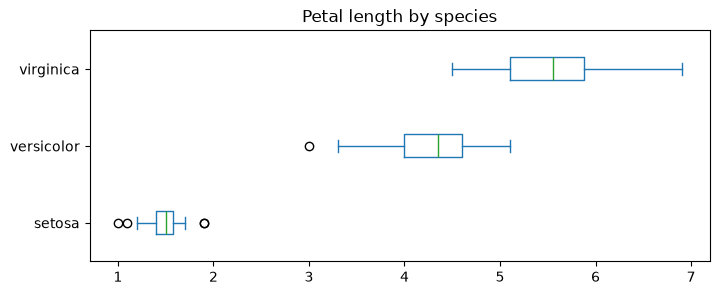

In [10]:
iris.pivot(index=a_w, columns=a_g, values=a_m).plot.box(vert=False, figsize=(8, 3))
plt.title('Petal length by species')
plt.show()

## Example 2

`iris` is unusually tidy: exactly $50$ flowers per species, no missing values, and already ordered by group.

Real data is rarely so accommodating. We use `penguins` to introduce three complications.

### Get the data

In [11]:
penguins = sns.load_dataset('penguins')

print(penguins.species.value_counts().to_string())
penguins.head()

species
Adelie       152
Gentoo       124
Chinstrap     68


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Choose the variables

In [12]:
b_w = 'within'
b_g = 'species'
b_m = 'body_mass_g'

### Check for uniqueness

In [13]:
penguins.value_counts([b_g]).head(1)

species
Adelie     152
Name: count, dtype: int64

Not unique, and again we need every observation. We manufacture $w$ as before.

In [14]:
penguins[b_w] = penguins.groupby(b_g).cumcount()

mass_by_species = penguins.pivot(index=b_w, columns=b_g, values=b_m)

print('shape:', mass_by_species.shape)
mass_by_species.tail(3)

shape: (152, 3)


species,Adelie,Chinstrap,Gentoo
within,,,
149,3750.0,NaN,NaN
150,3700.0,NaN,NaN
151,4000.0,NaN,NaN


### Complication 1: groups of different sizes

The three species contain $152$, $124$, and $68$ penguins.

$W$ therefore has as many rows as the largest group, and the shorter columns are padded with `NaN` at the bottom.

This is expected and harmless. Pandas' plotting functions ignore missing values, so each plot is drawn only from the observations that exist.

species
Adelie       151
Chinstrap     68
Gentoo       123


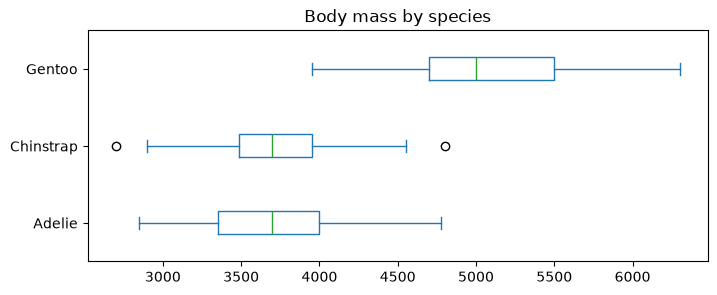

In [15]:
print(mass_by_species.count().to_string())

mass_by_species.plot.box(vert=False, figsize=(8, 3))
plt.title('Body mass by species')
plt.show()

> [!NOTE] The counts above are $151$, $68$, and $123$, not $152$, $68$, and $124$.
>
> Two penguins have no recorded body mass. They occupy a row in $W$ but contribute a `NaN` to it.

### Complication 2: more than one grouping variable

Nothing prevents $g$ from being a list. Pass it to `.groupby()` and to `columns`, and the result carries a hierarchical column index.

In [16]:
penguins[b_w] = penguins.groupby(['species', 'sex']).cumcount()

penguins.dropna(subset=['sex']).pivot(
    index=b_w, columns=['species', 'sex'], values=b_m).head(3)

species  Adelie         Chinstrap          Gentoo        
sex        Male  Female    Female    Male  Female    Male
within                                                   
0.0      3750.0  3800.0    3500.0  3900.0  4500.0  5700.0
1.0      3650.0  3250.0    3525.0  3650.0  4450.0  5700.0
2.0      4675.0  3450.0    3950.0  3725.0  4550.0  5400.0

If you would rather have flat labels, combine the grouping variables into one column first. `.str.cat()` does this, and it yields `NaN` wherever either part is missing.

In [17]:
penguins['group'] = penguins.species.str.cat(penguins.sex, sep=' ')
penguins[b_w] = penguins.groupby('group').cumcount()

penguins.dropna(subset=['group']).pivot(
    index=b_w, columns='group', values=b_m).count()

group
Adelie Female       73
Adelie Male         73
Chinstrap Female    34
Chinstrap Male      34
Gentoo Female       58
Gentoo Male         61
dtype: int64

### Complication 3: missing values in a grouping variable

You will have noticed the `.dropna()` in the last two examples. It is required, and the reason is worth understanding.

`.groupby()` ignores rows whose grouping value is missing. Those rows belong to no group, so `.cumcount()` has no number to give them.

In [18]:
penguins[b_w] = penguins.groupby('sex').cumcount()

penguins.loc[penguins.sex.isna(), ['species', 'sex', b_w]].head()

,species,sex,within
3,Adelie,NaN,NaN
8,Adelie,NaN,NaN
9,Adelie,NaN,NaN
10,Adelie,NaN,NaN
11,Adelie,NaN,NaN


Every such row receives `NaN` as its within-group ID.

If there is more than one of them, they all share the same index value, and the reshape fails.

In [19]:
try:
    penguins.pivot(index=b_w, columns='sex', values=b_m)
except ValueError as e:
    print('ValueError:', e)

ValueError: Index contains duplicate entries, cannot reshape


The message names duplicate entries in the index, which is accurate but not obvious. The duplicates are the missing values.

The fix is to drop those rows before reshaping.

In [20]:
penguins.dropna(subset=['sex']).pivot(index=b_w, columns='sex', values=b_m).count()

sex
Female    165
Male      168
dtype: int64

> [!CAUTION] Assign $w$ first, then drop, then reshape.
>
> Dropping the rows before calling `.cumcount()` also works, but it changes the dataframe you are working with. This order leaves $D$ intact.

## What $W$ means, and what it does not

The manufactured $w$ is a position, not a measurement. It carries no information about the observation.

This limits how $W$ may be used.

> [!WARNING] The rows of $W$ are not aligned in any meaningful way.
>
> The setosa on row $7$ has nothing to do with the virginica on row $7$. Each is simply the eighth flower of its species in the order the file happened to list them.
>
> It would be a mistake to subtract one column from another, to correlate them, or to treat a row as an observation.

Compare this with the wide table from the previous notebook, where row $1970$ genuinely means *the year 1970* in every column. There, reading across a row is meaningful. Here it is not.

A $W$ built on a manufactured index is a convenience for plotting, not a tidy dataset. Build it, plot it, and return to $D$ for anything else.

## Controlling the order

`.cumcount()` numbers rows in the order they appear in $D$. It does not sort anything.

So if the numbering should mean something, sort $D$ first.

Sorting by the measurement, for instance, makes each column of $W$ ascend.

In [21]:
iris_sorted = iris.sort_values([a_g, a_m])
iris_sorted[a_w] = iris_sorted.groupby(a_g).cumcount()

iris_sorted.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within,,,
0,1.0,3.0,4.5
1,1.1,3.3,4.8
2,1.2,3.3,4.8
3,1.2,3.5,4.9
4,1.3,3.5,4.9


For a box plot or a histogram this makes no difference, since those plots do not care in what order the values arrive.

It matters when you want $W$ to be readable, or when you intend to take the first $n$ rows of each group.

You can see the result more clearly below.

We take a sample from the datafraem and sort by index.

You can also see what we want: have all the data sit side-by-side. 

This requires creating and ID value that restarts with each species.

In [40]:
staircase.sample(20).sort_index().fillna('').style.background_gradient()

species,setosa,versicolor,virginica
0,1.400000,,
1,1.400000,,
2,1.300000,,
9,1.500000,,
10,1.500000,,
17,1.400000,,
47,1.400000,,
51,,4.500000,
54,,4.600000,
57,,3.300000,


## General Function

As before, let's define a general function that takes a tidy dataframe as its first argument and returns a wide dataframe.

This one takes $g$ and $m$ only, since $w$ is manufactured rather than supplied.

In [42]:
def tidy2wide_all(tidy, g, m, w='within', method='pivot', sort_by=None):

    D = tidy.copy()

    # Sort first if the numbering should mean something
    if sort_by is not None:
        D = D.sort_values(sort_by)

    # Manufacture the index
    D[w] = D.groupby(g).cumcount()

    # Rows with a missing grouping value got no number, so remove them
    keys = [g] if isinstance(g, str) else list(g)
    D = D.dropna(subset=keys)

    if method == 'pivot':
        wide = D.pivot(index=w, columns=g, values=m)
    elif method == 'unstack':
        wide = D.set_index([w] + keys)[m].unstack(keys)
    else:
        raise ValueError("Invalid method.")

    return wide

In [43]:
tidy2wide_all(iris, 'species', 'petal_length').head()

species,setosa,versicolor,virginica
within,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


In [45]:
tidy2wide_all(penguins, 'species', 'body_mass_g', method='unstack').count()

species
Adelie       151
Chinstrap     68
Gentoo       123
dtype: int64

In [46]:
tidy2wide_all(penguins, ['species', 'sex'], 'body_mass_g').count()

species    sex   
Adelie     Male      73
           Female    73
Chinstrap  Female    34
           Male      34
Gentoo     Female    58
           Male      61
dtype: int64

In [47]:
tidy2wide_all(iris, 'species', 'petal_length', sort_by=['species', 'petal_length']).head()

species,setosa,versicolor,virginica
within,,,
0,1.0,3.0,4.5
1,1.1,3.3,4.8
2,1.2,3.3,4.8
3,1.2,3.5,4.9
4,1.3,3.5,4.9


## Summary

:::{table}
| Condition | Method |
| --- | --- |
| $g_1 \times g_2$ is unique | `.pivot()` or `.set_index().unstack()` |
| Not unique, one summary value per cell is acceptable | `.pivot_table()` or `.groupby().unstack()` |
| Not unique, every observation must be kept | Manufacture $w$ with `.cumcount()`, then either method above |
:::

Three things to remember about the third row.

`.cumcount()` numbers rows in the order they appear, restarting at each group. Sort $D$ first if the order should mean something.

Groups of different sizes produce a ragged $W$ padded with `NaN`. This is normal, and plotting functions handle it.

$W$ is not tidy. Its rows are not observations, and reading across a row is meaningless.